# Parameter Grid Search

This notebook demonstrates `lsp.grid_search()` to systematically test Suite2p parameter combinations.

**Use cases:**
- Optimize detection parameters (`threshold_scaling`, `tau`, `diameter`)
- Compare functional vs anatomical (Cellpose) detection
- Find best parameters for different tissue types or imaging conditions

**How it works:**
1. Specify parameters to search with `grid_params`
2. Optionally provide base `ops` dictionary with fixed parameters
3. `grid_search` tests all combinations and saves results to separate folders

In [7]:
import numpy as np
from pathlib import Path
import lbm_suite2p_python as lsp

# === CONFIGURE PATHS ===
data_dir = Path(r"D:/demo/data")          # Directory containing input files
save_path = Path(r"D:/demo/grid_search")  # Output directory

# Single plane tiff for grid search
input_file = data_dir / "plane01_stitched.tif"

print(f"Input: {input_file}")
print(f"Output: {save_path}")
print(f"Exists: {input_file.exists()}")

Input: D:\demo\data\plane01_stitched.tif
Output: D:\demo\grid_search
Exists: True


## Define Grid Search Parameters

Choose which parameters to search. Common choices:

| Parameter | Description | Typical Range |
|-----------|-------------|---------------|
| `spatial_hp_detect` | High-pass filter for detection | 0 - 50 |
| `threshold_scaling` | Detection sensitivity (lower = more ROIs) | 0.5 - 2.0 |
| `tau` | Calcium indicator decay time | 0.5 - 2.0 s |
| `diameter` | Expected cell diameter in pixels | 4 - 15 px |

In [8]:
# Grid search high-pass filter values
grid_params = {
    "spatial_hp_detect": [0, 10, 25, 50],
}

# Use default ops
ops = None

# Show combinations
n_combos = np.prod([len(v) for v in grid_params.values()])
print(f"Parameters: {list(grid_params.keys())}")
print(f"Total combinations: {n_combos}")

Parameters: ['spatial_hp_detect']
Total combinations: 4


## Run Grid Search

Each parameter combination is saved to a separate subdirectory.

In [9]:
# Run grid search
lsp.grid_search(
    input_file=input_file,
    save_path=save_path,
    grid_params=grid_params,
    ops=ops,
    force_reg=False,    # Skip registration if already done
    force_detect=True,  # Re-run detection for each combination
)

Importing suite2p packages...
Grid search: D:\demo\grid_search
Parameters: ['spatial_hp_detect']
Total combinations: 4

[1/4] spa0
Importing suite2p packages...
Roi detection forced for plane 1.
Skipping data_raw.bin write, already exists and passes data validation checks.
Registration already complete, skipping despite do_registration=1 in ops
Registration skipped - copying data_raw.bin to data.bin...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 13


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [121,534,430] created in 0.79 sec.
>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 6.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is depricated in v4.0.1+


>>>> 505 masks detected, median diameter = 12.05 
Detected 505 ROIs, 7.76 sec
After removing overlaps, 505 ROIs remain
----------- Total 9.18 sec.
----------- EXTRACTION
Masks created, 0.71 sec.
Extracted fluorescence from 505 ROIs in 1574 frames, 0.84 sec.
----------- Total 1.63 sec.
----------- CLASSIFICATION
['skew', 'compact', 'npix_norm']
----------- SPIKE DECONVOLUTION
----------- Total 0.03 sec.
Saved panel TIFF to D:\demo\grid_search\spa0\plane01_stitched\pc_metrics_panels.tif
Saved metrics CSV to D:\demo\grid_search\spa0\plane01_stitched\pc_metrics.csv
   Rigid    Avg_NR    Max_NR
0    0.0  0.046224  0.200000
1    0.0  0.044421  0.200000
2    0.0  0.031530  0.141421
3    0.0  0.031939  0.141421
4    0.0  0.039659  0.200000
Plotting results for 427 accepted / 78 rejected ROIs
  Saved: 05_quality_diagnostics.png

[2/4] spa10
Importing suite2p packages...


...

NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 8.13 sec.
Registered 500/1574 in 7.80s
Registered 1000/1574 in 15.43s
Registered 1500/1574 in 23.13s
Registered 1574/1574 in 24.63s
----------- Total 34.25 sec
Registration metrics, 10.35 sec.
----------- ROI DETECTION
Binning movie in chunks of length 13


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [121,534,430] created in 0.59 sec.
>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 6.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is depricated in v4.0.1+


>>>> 505 masks detected, median diameter = 12.05 
Detected 505 ROIs, 7.53 sec
After removing overlaps, 505 ROIs remain
----------- Total 8.73 sec.
----------- EXTRACTION
Masks created, 0.73 sec.
Extracted fluorescence from 505 ROIs in 1574 frames, 0.82 sec.
----------- Total 1.64 sec.
----------- CLASSIFICATION
['skew', 'compact', 'npix_norm']
----------- SPIKE DECONVOLUTION
----------- Total 0.03 sec.
Saved panel TIFF to D:\demo\grid_search\spa50\plane01_stitched\pc_metrics_panels.tif
Saved metrics CSV to D:\demo\grid_search\spa50\plane01_stitched\pc_metrics.csv
   Rigid    Avg_NR    Max_NR
0    0.0  0.046224  0.200000
1    0.0  0.044421  0.200000
2    0.0  0.031530  0.141421
3    0.0  0.031939  0.141421
4    0.0  0.039659  0.200000
Plotting results for 427 accepted / 78 rejected ROIs
  Saved: 05_quality_diagnostics.png

Grid search complete: 4 combinations
Results in: D:\demo\grid_search


## Analyze Results

Collect quality metrics from all runs: SNR, skewness, and shot noise distributions.

In [ ]:
import pandas as pd
from scipy.stats import skew

def compute_quality_metrics(F, Fneu, stat, iscell, fs=30.0):
    """
    Compute SNR, skewness, and shot noise for accepted cells.

    Returns dict with median and IQR for each metric.
    """
    mask = iscell[:, 0].astype(bool)
    n_accepted = mask.sum()

    if n_accepted == 0:
        return {
            "n_accepted": 0, "n_rejected": len(mask),
            "snr_median": np.nan, "snr_iqr": np.nan,
            "skew_median": np.nan, "skew_iqr": np.nan,
            "noise_median": np.nan, "noise_iqr": np.nan,
        }

    # Filter to accepted cells
    F_acc = F[mask]
    Fneu_acc = Fneu[mask]
    stat_acc = [s for s, m in zip(stat, mask) if m]

    # Neuropil-corrected fluorescence
    F_corr = F_acc - 0.7 * Fneu_acc

    # Baseline (20th percentile)
    baseline = np.percentile(F_corr, 20, axis=1, keepdims=True)
    baseline = np.maximum(baseline, 1e-6)

    # ΔF/F
    dff = (F_corr - baseline) / baseline

    # SNR: signal (std of dff) / noise (MAD estimator)
    signal = np.std(dff, axis=1)
    noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / 0.6745
    snr = signal / (noise + 1e-6)

    # Shot noise: MAD of frame differences, normalized by sqrt(framerate)
    shot_noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / np.sqrt(fs)

    # Skewness: from stat if available, else compute
    skewness = []
    for i, s in enumerate(stat_acc):
        if "skew" in s:
            skewness.append(s["skew"])
        else:
            skewness.append(skew(dff[i]))
    skewness = np.array(skewness)

    return {
        "n_accepted": n_accepted,
        "n_rejected": len(mask) - n_accepted,
        "snr_median": np.median(snr),
        "snr_iqr": np.percentile(snr, 75) - np.percentile(snr, 25),
        "skew_median": np.median(skewness),
        "skew_iqr": np.percentile(skewness, 75) - np.percentile(skewness, 25),
        "noise_median": np.median(shot_noise),
        "noise_iqr": np.percentile(shot_noise, 75) - np.percentile(shot_noise, 25),
    }

def find_ops_file(combo_dir):
    """Find ops.npy in combo directory, checking common locations."""
    # Direct location (new grid_search output)
    ops_file = combo_dir / "ops.npy"
    if ops_file.exists():
        return ops_file
    
    # Check for subdirectories (legacy output or run_plane subdir)
    for subdir in combo_dir.iterdir():
        if subdir.is_dir():
            ops_file = subdir / "ops.npy"
            if ops_file.exists():
                return ops_file
    return None

# Collect results
results = []

for combo_dir in save_path.iterdir():
    if not combo_dir.is_dir():
        continue
    
    # Skip non-parameter directories
    if combo_dir.name in ("grid_search_results.csv",):
        continue

    ops_file = find_ops_file(combo_dir)
    if ops_file is None:
        continue

    try:
        res = lsp.load_planar_results(ops_file)
        loaded_ops = lsp.load_ops(ops_file)
        fs = loaded_ops.get("fs", 30.0)

        # Compute quality metrics
        metrics = compute_quality_metrics(
            res["F"], res["Fneu"], res["stat"], res["iscell"], fs
        )

        # Use outer directory name (the grid search tag)
        result = {"combo": combo_dir.name, "ops_file": str(ops_file), **metrics}

        # Add grid search parameters
        for param in grid_params.keys():
            result[param] = loaded_ops.get(param)

        results.append(result)

    except Exception as e:
        print(f"Skipping {combo_dir.name}: {e}")

# Create DataFrame
if results:
    df = pd.DataFrame(results)

    # Sort by SNR (higher is better)
    df = df.sort_values("snr_median", ascending=False)

    print("Quality Metrics (sorted by median SNR):")
    print("=" * 100)
    display_cols = ["combo", "n_accepted", "snr_median", "skew_median", "noise_median"] + list(grid_params.keys())
    print(df[display_cols].to_string(index=False))

    # Save
    csv_path = save_path / "grid_search_results.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nSaved to: {csv_path}")
else:
    print("No results found!")
    df = pd.DataFrame()

## Visualize Quality Metrics

Compare SNR, skewness, and shot noise distributions across parameter combinations.

Saved: D:\demo\grid_search\quality_metrics.png


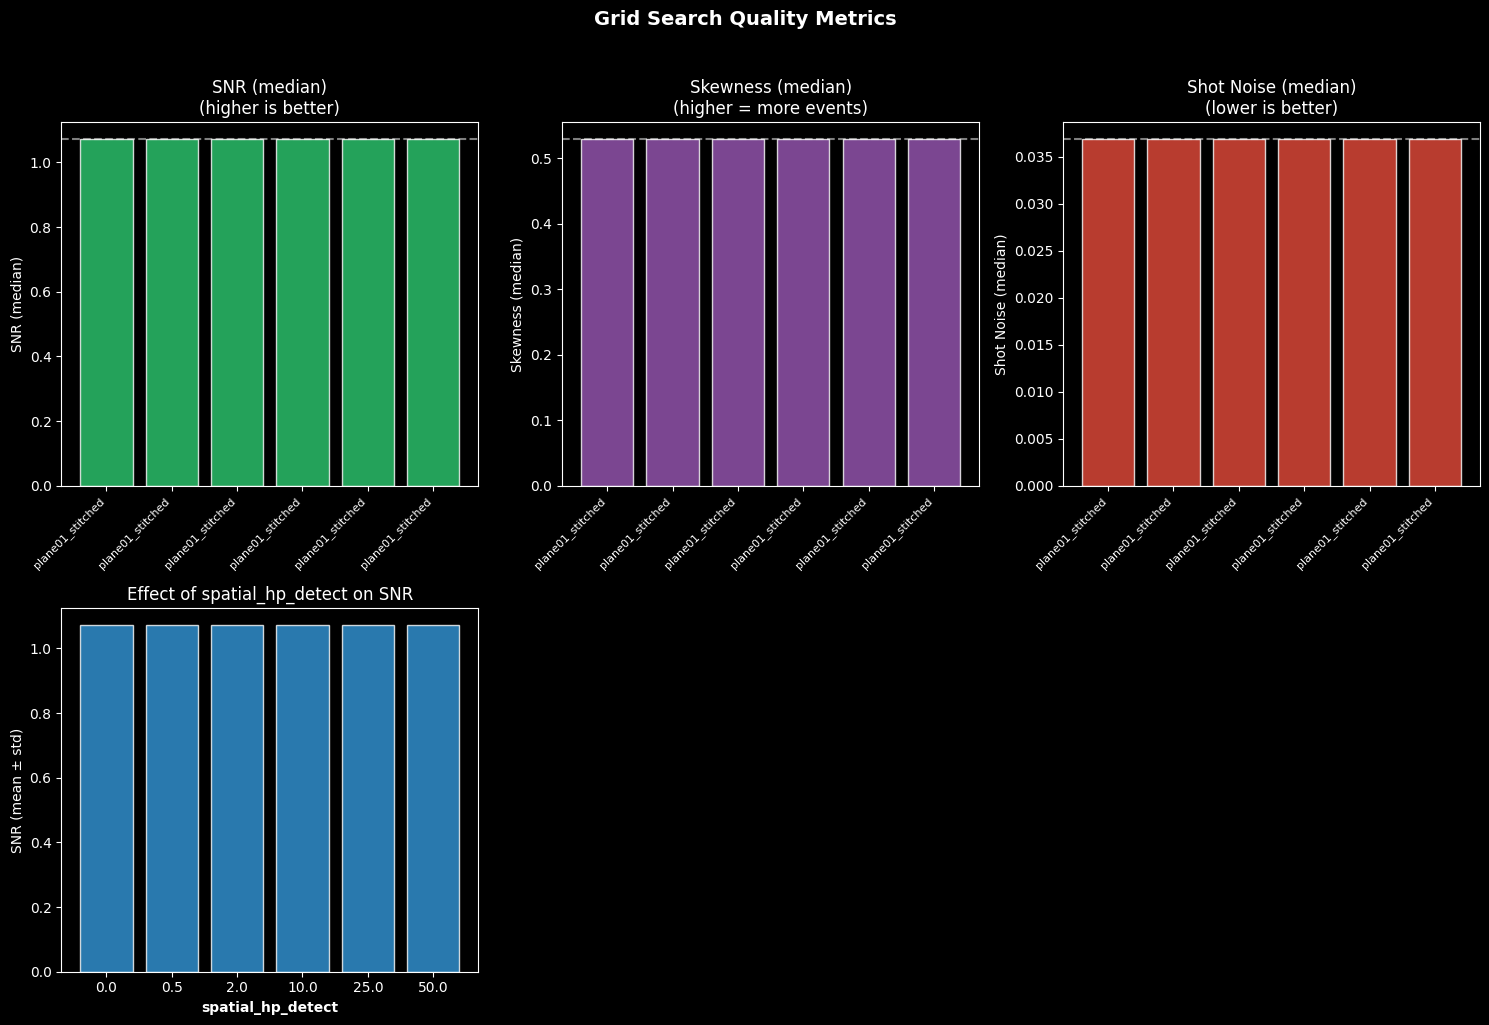

In [14]:
import matplotlib.pyplot as plt

if len(df) > 0:
    plt.style.use('dark_background')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    metrics = [
        ("snr_median", "SNR (median)", "higher is better", "#2ecc71"),
        ("skew_median", "Skewness (median)", "higher = more events", "#9b59b6"),
        ("noise_median", "Shot Noise (median)", "lower is better", "#e74c3c"),
    ]

    # Row 1: Metrics by parameter
    params = list(grid_params.keys())

    for col, (metric, label, note, color) in enumerate(metrics):
        ax = axes[0, col]

        # Bar chart of metric values
        x = range(len(df))
        ax.bar(x, df[metric], color=color, alpha=0.8, edgecolor="white")
        ax.set_xticks(x)
        ax.set_xticklabels(df["combo"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f"{label}\n({note})")
        ax.axhline(df[metric].median(), color="white", linestyle="--", alpha=0.5, label="median")

    # Row 2: Parameter effects on SNR
    for col, param in enumerate(params[:3]):  # Show up to 3 params
        ax = axes[1, col]

        grouped = df.groupby(param)["snr_median"].agg(["mean", "std"]).reset_index()
        x = range(len(grouped))
        ax.bar(x, grouped["mean"], yerr=grouped["std"],
               color="#3498db", alpha=0.8, edgecolor="white", capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped[param]])
        ax.set_xlabel(param, fontweight="bold")
        ax.set_ylabel("SNR (mean ± std)")
        ax.set_title(f"Effect of {param} on SNR")

    # Hide unused subplots
    for col in range(len(params), 3):
        axes[1, col].axis("off")

    plt.suptitle("Grid Search Quality Metrics", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    fig_path = save_path / "quality_metrics.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="black")
    print(f"Saved: {fig_path}")
    plt.show()

## Distribution Comparison

Compare the full distributions of SNR, skewness, and shot noise for top combinations.

In [ ]:
if len(df) > 0:
    # Get top 4 by SNR
    top_combos = df.head(4)["combo"].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]

    for combo, color in zip(top_combos, colors):
        combo_dir = save_path / combo
        ops_file = find_ops_file(combo_dir)
        if ops_file is None:
            continue

        try:
            res = lsp.load_planar_results(ops_file)
            loaded_ops = lsp.load_ops(ops_file)
            fs = loaded_ops.get("fs", 30.0)

            mask = res["iscell"][:, 0].astype(bool)
            if mask.sum() == 0:
                continue

            F_acc = res["F"][mask]
            Fneu_acc = res["Fneu"][mask]
            stat_acc = [s for s, m in zip(res["stat"], mask) if m]

            F_corr = F_acc - 0.7 * Fneu_acc
            baseline = np.percentile(F_corr, 20, axis=1, keepdims=True)
            baseline = np.maximum(baseline, 1e-6)
            dff = (F_corr - baseline) / baseline

            # SNR
            signal = np.std(dff, axis=1)
            noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / 0.6745
            snr = signal / (noise + 1e-6)

            # Shot noise
            shot_noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / np.sqrt(fs)

            # Skewness
            skewness = np.array([s.get("skew", skew(dff[i])) for i, s in enumerate(stat_acc)])

            # Plot distributions
            axes[0].hist(snr, bins=30, alpha=0.5, color=color, label=combo, density=True)
            axes[1].hist(skewness, bins=30, alpha=0.5, color=color, label=combo, density=True)
            axes[2].hist(shot_noise, bins=30, alpha=0.5, color=color, label=combo, density=True)

        except Exception as e:
            print(f"Error loading {combo}: {e}")

    axes[0].set_xlabel("SNR")
    axes[0].set_ylabel("Density")
    axes[0].set_title("SNR Distribution")
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel("Skewness")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Skewness Distribution")

    axes[2].set_xlabel("Shot Noise")
    axes[2].set_ylabel("Density")
    axes[2].set_title("Shot Noise Distribution")

    plt.suptitle("Quality Metric Distributions (Top 4 by SNR)", fontweight="bold", y=1.02)
    plt.tight_layout()

    fig_path = save_path / "metric_distributions.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="black")
    print(f"Saved: {fig_path}")
    plt.show()

## Compare Detection Masks

In [ ]:
if len(df) > 0:
    # Top 4 by SNR
    top_combos = df.head(4)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, top_combos.iterrows()):
        combo_dir = save_path / row["combo"]
        ops_file = find_ops_file(combo_dir)

        if ops_file is not None:
            loaded_ops = lsp.load_ops(ops_file)
            mean_img = loaded_ops.get("meanImg", loaded_ops.get("refImg", np.zeros((512, 512))))

            ax.imshow(mean_img, cmap="gray",
                      vmin=np.percentile(mean_img, 1),
                      vmax=np.percentile(mean_img, 99))

            # Draw ROIs
            stat_file = ops_file.parent / "stat.npy"
            iscell_file = ops_file.parent / "iscell.npy"

            if stat_file.exists() and iscell_file.exists():
                stat = np.load(stat_file, allow_pickle=True)
                iscell = np.load(iscell_file)[:, 0].astype(bool)

                for i, s in enumerate(stat):
                    if iscell[i]:
                        ax.scatter(s["xpix"], s["ypix"], s=0.1, c="lime", alpha=0.3)

            title = f"{row['combo']}\n{row['n_accepted']} cells, SNR={row['snr_median']:.2f}"
            ax.set_title(title, fontsize=10)

        ax.axis("off")

    plt.suptitle("Top 4 by SNR", fontsize=14, fontweight="bold")
    plt.tight_layout()

    fig_path = save_path / "detection_comparison.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="black")
    print(f"Saved: {fig_path}")
    plt.show()

## Best Parameters Summary

In [ ]:
if len(df) > 0:
    print("Best Parameters by Different Criteria:")
    print("=" * 60)

    # Best by SNR (highest)
    best_snr = df.loc[df["snr_median"].idxmax()]
    print(f"\nHighest SNR: {best_snr['combo']}")
    print(f"  SNR: {best_snr['snr_median']:.3f}")
    print(f"  Cells: {best_snr['n_accepted']}")
    for p in grid_params:
        print(f"  {p}: {best_snr[p]}")

    # Best by skewness (highest = more events)
    best_skew = df.loc[df["skew_median"].idxmax()]
    print(f"\nHighest Skewness: {best_skew['combo']}")
    print(f"  Skewness: {best_skew['skew_median']:.3f}")
    print(f"  Cells: {best_skew['n_accepted']}")

    # Best by noise (lowest)
    best_noise = df.loc[df["noise_median"].idxmin()]
    print(f"\nLowest Shot Noise: {best_noise['combo']}")
    print(f"  Noise: {best_noise['noise_median']:.4f}")
    print(f"  Cells: {best_noise['n_accepted']}")

## Output Structure

```
grid_search/
├── grid_search_results.csv      # All metrics
├── quality_metrics.png          # Metric comparison
├── metric_distributions.png     # Distribution histograms
├── detection_comparison.png     # Mask visualization
├── spa0/
│   ├── ops.npy
│   ├── stat.npy
│   ├── F.npy
│   └── iscell.npy
├── spa10/
├── spa25/
└── spa50/
```

## Next Steps

1. Review `grid_search_results.csv` - sort by desired metric
2. Use best parameters in `lsp.run_volume()` for full processing
3. Consider trade-offs: higher SNR vs more cells vs lower noise